In [1]:
import boto3
import io
import os
import pickle

import neurokit2 as nk
import pandas as pd
import numpy as np

from tqdm import tqdm
import time
import random
from random import shuffle, randint, randrange
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.functional import relu
import torch.nn.functional as F

import wfdb

import scipy

import re

import warnings
warnings.simplefilter("ignore")

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
nk.__version__, wfdb.__version__

('0.2.13', '4.3.1')

In [3]:
# Initialize the S3 client
s3 = boto3.client('s3')

# Define the bucket name and prefix for the MIMIC-IV data
bucket_name = 'walkky-datasets' #S3 bucket that holds the data
prefix = 'mimic-iv/files_unzip/' #path inside the bucket

# Function to list all files in nested folders automatically
def list_all_files(bucket, prefix):
    files = []
    paginator = s3.get_paginator('list_objects_v2') #gives an iterator that automatically requests every page
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        files.extend([content['Key'] for content in page.get('Contents', [])]) #add full path of each object to files
    return files

# Get all files under the specified prefix
all_files = list_all_files(bucket_name, prefix)
filtered_file_names= [file for file in all_files if file.endswith('.dat') or file.endswith('.hea')]

print('number of files', len(all_files))
print('number of dat and hea files', len(filtered_file_names))


number of files 1600100
number of dat and hea files 1600070


In [4]:
# Function to read ECG signal data as a NumPy array
def read_data(dat_file_name):
    # Extract base name for temporary file paths
    base_name = os.path.basename(dat_file_name).split('.')[0]

    # print(dat_file_name)
    # Define the corresponding .hea file name based on the .dat file name
    hea_file_name = dat_file_name.replace('.dat', '.hea')

    # Define local temp file paths using the base file name
    temp_dat_path = f'/tmp/{base_name}.dat'
    temp_hea_path = f'/tmp/{base_name}.hea'

    # Download the .dat and .hea files from S3 into memory
    response_dat = s3.get_object(Bucket='walkky-datasets', Key=dat_file_name)
    response_hea = s3.get_object(Bucket='walkky-datasets', Key=hea_file_name)

    # Write the files to local temp storage
    with open(temp_dat_path, 'wb') as f:
        f.write(response_dat['Body'].read())
    with open(temp_hea_path, 'wb') as f:
        f.write(response_hea['Body'].read())

    # Read the ECG waveform using WFDB
    try:
        # Pass only the base name without extension to rdrecord
        record = wfdb.rdrecord(f'/tmp/{base_name}')

        # Extract the ECG signal data as a NumPy array
        ecg_data = record.p_signal  # This is the signal data, shape: [num_samples, num_leads]

        # Return the ECG data as a NumPy array
        return ecg_data

    except Exception as e:
        print(f"Failed to process {dat_file_name}: {e}")
        return None

    finally:
        # Clean up temporary files
        os.remove(temp_dat_path)
        os.remove(temp_hea_path)

#   Get only the .dat file names from filtered_file_names (even indexes)
dat_file_names = [f for f in filtered_file_names if f.endswith('.dat')]

print('number of dat files', len(dat_file_names))


number of dat files 800035


In [5]:
# Try an example file
print(dat_file_names[0])
read_data(dat_file_names[0])

mimic-iv/files_unzip/p1000/p10000032/s40689238/40689238.dat


array([[-0.155,  0.01 ,  0.15 , ...,  0.04 ,  0.08 ,  0.02 ],
       [-0.17 ,  0.01 ,  0.165, ...,  0.03 ,  0.08 ,  0.02 ],
       [-0.17 ,  0.   ,  0.155, ...,  0.025,  0.08 ,  0.01 ],
       ...,
       [-0.045,  0.01 ,  0.04 , ..., -0.02 , -0.02 , -0.2  ],
       [-0.055,  0.   ,  0.04 , ..., -0.02 , -0.02 , -0.2  ],
       [-0.075, -0.01 ,  0.05 , ..., -0.02 , -0.02 , -0.2  ]],
      shape=(5000, 12))

In [6]:
"""
ECG Extraction Pipeline
========================
For each file:
  1. Read raw ECG via WFDB
  2. Clean Lead II with NeuroKit2
  3. Detect R-peaks; skip file if < MIN_R_PEAKS
  4. Delineate P / QRS / T waveforms and PQ / ST segments on Lead II
  5. Skip file if any index array is empty (unidentifiable segment)
  6. Store Lead-II signal + shared indices (reusable for all 12 leads)

Output
------
results : list[dict]  – one entry per accepted file, keys below
drop_counts : dict    – breakdown of every drop reason
"""

# ── ECG processing constants ─────────────────────────────────────────────────
SAMPLING_RATE = 500
MIN_R_PEAKS   = 4          # minimum R peaks required per signal
LEAD_II_IDX   = 1          # 0-based column index for Lead II in the WFDB array


# The waves_info value returned by nk.ecg_delineate and readable name key
REQUIRED_SEGMENT_KEYS = {
    "p_peaks":       "ECG_P_Peaks",
    "p_onsets":      "ECG_P_Onsets",
    "p_offsets":     "ECG_P_Offsets",
    "q_peaks":       "ECG_Q_Peaks",
    "qrs_onsets":    "ECG_R_Onsets",    # Q-wave onset  (start of QRS)
    "qrs_offsets":   "ECG_R_Offsets",   # S-wave offset (end of QRS)
    "s_peaks":       "ECG_S_Peaks",
    "t_peaks":       "ECG_T_Peaks",
    "t_onsets":      "ECG_T_Onsets",
    "t_offsets":     "ECG_T_Offsets",
}


def _clean_index_array(raw) -> np.ndarray:
    """
    Convert a delineation array to a 1-D float array and strip NaN entries.
    NeuroKit2 fills undetected beats with NaN; we keep only valid indices.
    """
    arr = np.array(raw, dtype=float)
    return arr[~np.isnan(arr)].astype(int)


def _derive_segments(indices: dict) -> dict:
    """
    Derive PQ and ST segment boundary arrays from waveform boundary indices.

    PQ segment : P-wave offset  → QRS onset   (per beat)
    ST segment : QRS offset     → T-wave onset (per beat)

    Both are stored as (N, 2) int arrays: [[start, end], ...].
    Beats where either boundary is missing are silently dropped.
    """
    def _pair(starts, ends):
        pairs = [
            [s, e] for s, e in zip(starts, ends)
            if not (np.isnan(s) or np.isnan(e))
        ]
        return np.array(pairs, dtype=int) if pairs else np.empty((0, 2), dtype=int)

    pq = _pair(indices["p_offsets"], indices["qrs_onsets"])
    st = _pair(indices["qrs_offsets"], indices["t_onsets"])
    return {"pq_segments": pq, "st_segments": st}


def extract_ecg_features(
    dat_file_names: list[str],
    read_data,                      # callable: filename → np.ndarray | None
    lead_idx: int = LEAD_II_IDX,
    sampling_rate: int = SAMPLING_RATE,
    min_r_peaks: int = MIN_R_PEAKS,
) -> tuple[list[dict], dict]:
    """
    Process every file in dat_file_names and return accepted results plus
    a detailed drop-count breakdown.

    Parameters
    ----------
    dat_file_names : list of filenames to process
    read_data      : function that takes a filename and returns a 2-D NumPy
                     array (samples × leads) or None on failure
    lead_idx       : column index of the lead used for delineation (default: Lead II)
    sampling_rate  : Hz (default 500)
    min_r_peaks    : files with fewer detected R-peaks are discarded

    Returns
    -------
    results : list[dict] with keys
        patient_id      – derived from filename
        study_id        – derived from filename
        signal          – cleaned Lead-II signal (1-D np.ndarray, 5000 pts)
        r_peaks         – 1-D int array of R-peak sample indices
        indices         – dict of 1-D int arrays for every waveform/segment:
                            p_peaks, p_onsets, p_offsets,
                            q_peaks, qrs_onsets, qrs_offsets, s_peaks,
                            t_peaks, t_onsets, t_offsets,
                            pq_segments  (N×2 array: [start, end] per beat)
                            st_segments  (N×2 array: [start, end] per beat)
        NOTE: indices are computed on lead_idx but are valid for all leads
              because every lead shares the same sampling grid.

    drop_counts : dict
        failed_read          – file returned None from read_data
        too_few_r_peaks      – fewer than min_r_peaks R-peaks detected
        incomplete_segments  – one or more required segment arrays were empty
        accepted             – files kept
    """

    drop_counts = {
        "failed_read":         0,
        "too_few_r_peaks":     0,
        "incomplete_segments": 0,
        "accepted":            0,
    }
    results: list[dict] = []

    for filename in tqdm(dat_file_names, desc="Processing ECG files"):

        # ── 1. read ───────────────────────────────────────────────────────────
        ecg_data = read_data(filename)
        if ecg_data is None:
            drop_counts["failed_read"] += 1
            continue

        # ── 2. isolate lead & clean ───────────────────────────────────────────
        raw_lead = ecg_data[:, lead_idx]
        clean_lead = nk.ecg_clean(raw_lead, sampling_rate=sampling_rate)

        # ── 3. R-peak detection ───────────────────────────────────────────────
        try:
            _, rpeaks_info = nk.ecg_peaks(clean_lead, sampling_rate=sampling_rate)
        except Exception:
            drop_counts["too_few_r_peaks"] += 1
            continue

        r_peaks = rpeaks_info["ECG_R_Peaks"]
        if len(r_peaks) < min_r_peaks:
            drop_counts["too_few_r_peaks"] += 1
            continue

        # ── 4. waveform delineation (P / QRS / T) ────────────────────────────
        try:
            _, waves_info = nk.ecg_delineate(
                clean_lead,
                rpeaks_info,
                sampling_rate=sampling_rate,
                method="dwt",
                show=False,
            )
        except Exception:
            drop_counts["incomplete_segments"] += 1
            continue

        # ── 5. build & validate index arrays ─────────────────────────────────
        indices: dict[str, np.ndarray] = {}
        drop_this = False

        for k, v in REQUIRED_SEGMENT_KEYS.items():
            cleaned = _clean_index_array(waves_info[v])
            if cleaned.size == 0:
                drop_this = True
                break
            indices[k] = cleaned

        if drop_this:
            drop_counts["incomplete_segments"] += 1
            continue

        # ── 6. derive PQ / ST segment boundary pairs ─────────────────────────
        # Pass the raw (NaN-preserved) arrays for safe pairing
        raw_indices_for_pairing = {k: waves_info[v] for k, v in REQUIRED_SEGMENT_KEYS.items()}
        segments = _derive_segments(raw_indices_for_pairing)

        if segments["pq_segments"].shape[0] == 0 or segments["st_segments"].shape[0] == 0:
            drop_counts["incomplete_segments"] += 1
            continue

        indices.update(segments)

        # ── 7. derive patient id and study id from filename ─────────────────
        match = re.search(r'/p(\d+)/s(\d+)/', filename)
        patient_id = match.group(1)
        study_id = match.group(2)

        # ── 8. store ──────────────────────────────────────────────────────────
        results.append(
            {
                "patient_id": patient_id,
                "study_id":  study_id,
                "signal":     clean_lead,   # 1-D, length 5000
                "r_peaks":    r_peaks,
                #
                # indices below are derived from lead_idx (Lead II by default).
                # They are sample-position indices on the shared time axis, so
                # you can apply them directly to any other lead column:
                #   other_lead_segment = ecg_data[:, other_idx][indices["qrs_onsets"] : indices["qrs_offsets"]]
                "indices":    indices,
            }
        )
        drop_counts["accepted"] += 1

    return results, drop_counts


def print_summary(drop_counts: dict) -> None:
    total = sum(drop_counts.values())
    print("\n" + "=" * 50)
    print("  ECG Extraction Summary")
    print("=" * 50)
    print(f"  Total files processed : {total}")
    print(f"  ✓ Accepted            : {drop_counts['accepted']}")
    print(f"  ✗ Failed reads        : {drop_counts['failed_read']}")
    print(f"  ✗ Too few R-peaks     : {drop_counts['too_few_r_peaks']}  (< {MIN_R_PEAKS})")
    print(f"  ✗ Incomplete segments : {drop_counts['incomplete_segments']}")
    print("=" * 50)

In [7]:
sample_size = 10000
random_indices = np.random.choice(len(dat_file_names), sample_size, replace=False)
sampled_files = [dat_file_names[i] for i in random_indices]
results, drop_counts = extract_ecg_features(sampled_files, read_data)

# ── Accessing results ─────────────────────────────────────────────────────
i = 0
print(results[i]["signal"],
      results[i]["r_peaks"])
print("p onsets and offsets: ", results[i]['indices']["p_onsets"], results[i]['indices']["p_offsets"])
print("qrs onsets and offsets: ", results[i]['indices']["qrs_onsets"], results[i]['indices']["qrs_offsets"])
print("t onsets and offsets: ", results[i]['indices']["t_onsets"], results[i]['indices']["t_offsets"])

Processing ECG files: 100%|██████████| 10000/10000 [43:41<00:00,  3.81it/s]

[ 0.00287453  0.00011075 -0.00290305 ...  0.09227339  0.09119104
  0.09111406] [ 153  912 1572 2181 2780 3362 3928 4498 4970]
p onsets and offsets:  [ 817 1460 2070 2661 3252 3810 4375 4843] [ 867 1521 2125 2733 3305 3877 4441 4864]
qrs onsets and offsets:  [ 877 1542 2149 2748 3331 3895 4468 4904] [ 189  947 1615 2213 2816 3403 3961 4537]
t onsets and offsets:  [ 972 1641 2320 2848 3538 3979 4565] [ 217  993 1661 2374 2870 3591 4002 4590]


In [8]:
print(results[i]['indices'].keys())

dict_keys(['p_peaks', 'p_onsets', 'p_offsets', 'q_peaks', 'qrs_onsets', 'qrs_offsets', 's_peaks', 't_peaks', 't_onsets', 't_offsets', 'pq_segments', 'st_segments'])


In [9]:
print_summary(drop_counts)


  ECG Extraction Summary
  Total files processed : 10000
  ✓ Accepted            : 9745
  ✗ Failed reads        : 0
  ✗ Too few R-peaks     : 136  (< 4)
  ✗ Incomplete segments : 119


 P waves min, max, median, 99th quantile:  3 552 48.0 88.0
 QRS waves min, max, median, 99th quantile:  19 4808 85.0 1774.0
 T waves min, max, median, 99th quantile:  6 2313 62.0 124.0
 PQ segments min, max, median, 99th quantile:  2 4705 23.0 1459.0
 ST segments min, max, median, 99th quantile:  2 3469 62.0 572.0


(array([8.7739e+04, 3.6000e+03, 2.0700e+02, 2.4000e+01, 8.0000e+00,
        6.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00]),
 array([2.0000e+00, 3.4870e+02, 6.9540e+02, 1.0421e+03, 1.3888e+03,
        1.7355e+03, 2.0822e+03, 2.4289e+03, 2.7756e+03, 3.1223e+03,
        3.4690e+03]),
 <BarContainer object of 10 artists>)

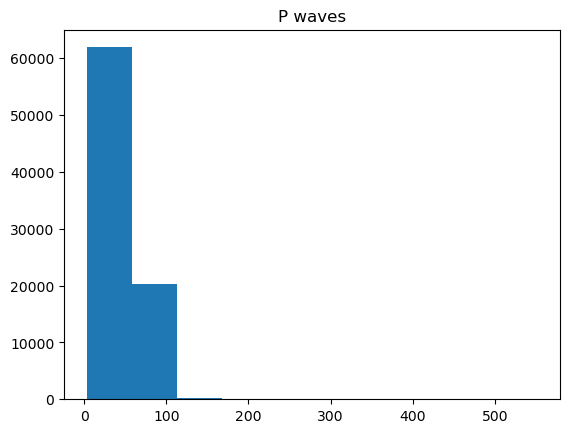

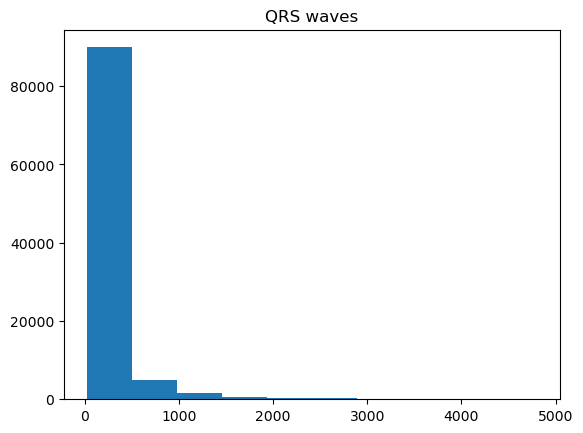

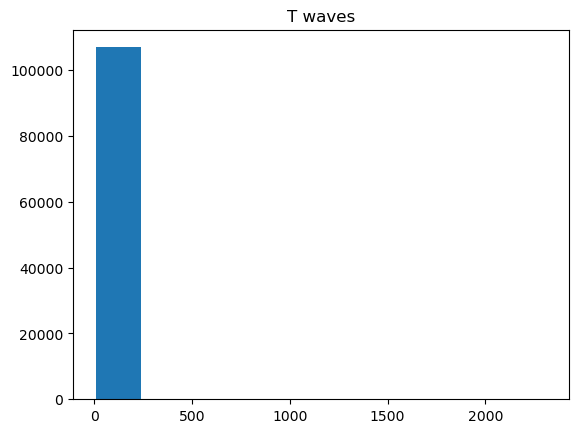

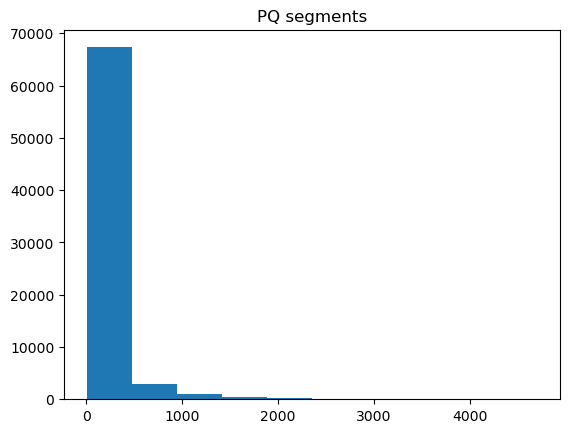

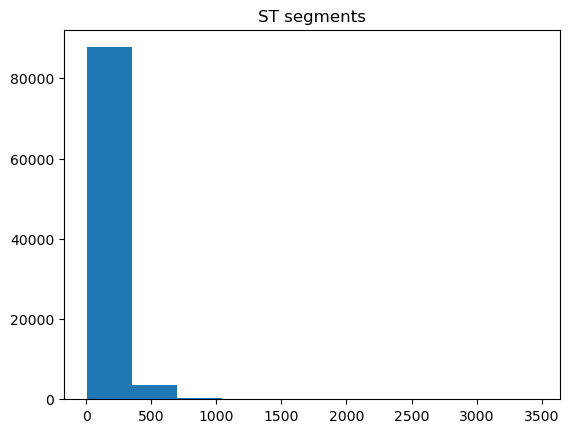

In [10]:
def _extract_waveform(
    signal: np.ndarray,
    start: int,
    end: int,
) -> np.ndarray | None:
    """
    Slice [start:end] from signal, resample to target_len, and z-normalise.
    Returns None if the slice is degenerate (zero or negative length).
    """
    if end <= start or start < 0 or end > len(signal):
        return None
    extracted = signal[start:end]
    if len(extracted) < 2:
        return None
    return extracted


def collect_waveforms(results, onset, offset):
    waveforms = []
    waveforms_len = []

    for i in range(len(results)):
        signal = results[i]["signal"]
        starts = results[i]["indices"][onset]
        ends = results[i]["indices"][offset]
        for start, end in zip(starts, ends):
            waveform = _extract_waveform(signal, start, end)
            if waveform is None:
                continue
            waveforms.append(waveform)
            waveforms_len.append(len(waveform))

    return waveforms, waveforms_len


# P
pwaves, pwaves_len = collect_waveforms(results, "p_onsets", "p_offsets")
print(" P waves min, max, median, 99th quantile: ", min(pwaves_len), max(pwaves_len), np.median(pwaves_len), np.quantile(pwaves_len, 0.99))

plt.figure()
plt.title("P waves")
plt.hist(pwaves_len)


# QRS
qrswaves, qrswaves_len = collect_waveforms(results, "qrs_onsets", "qrs_offsets")
print(" QRS waves min, max, median, 99th quantile: ", min(qrswaves_len), max(qrswaves_len), np.median(qrswaves_len), np.quantile(qrswaves_len, 0.99))

plt.figure()
plt.title("QRS waves")
plt.hist(qrswaves_len)


# T
twaves, twaves_len = collect_waveforms(results, "t_onsets", "t_offsets")
print(" T waves min, max, median, 99th quantile: ", min(twaves_len), max(twaves_len), np.median(twaves_len), np.quantile(twaves_len, 0.99))

plt.figure()
plt.title("T waves")
plt.hist(twaves_len)


# PQ
pqseg, pqseg_len = collect_waveforms(results, "p_offsets", "qrs_onsets")
print(" PQ segments min, max, median, 99th quantile: ", min(pqseg_len), max(pqseg_len), np.median(pqseg_len), np.quantile(pqseg_len, 0.99))

plt.figure()
plt.title("PQ segments")
plt.hist(pqseg_len)

# ST

stseg, stseg_len = collect_waveforms(results, "qrs_offsets", "t_onsets")
print(" ST segments min, max, median, 99th quantile: ", min(stseg_len), max(stseg_len), np.median(stseg_len), np.quantile(stseg_len, 0.99))

plt.figure()
plt.title("ST segments")
plt.hist(stseg_len)


In [11]:
del results

In [12]:
scipy.stats.percentileofscore(pwaves_len, 1000) # P waves

np.float64(99.99999999999999)

In [13]:
scipy.stats.percentileofscore(qrswaves_len, 1000) # QRS waves

np.float64(96.96281244894625)

In [14]:
scipy.stats.percentileofscore(twaves_len, 1000) # T waves

np.float64(99.97203813997707)

In [15]:
scipy.stats.percentileofscore(pqseg_len, 1000) # PQ segments

np.float64(97.68549326235235)

In [16]:
scipy.stats.percentileofscore(stseg_len, 1000) # ST segments

np.float64(99.94540829138872)

In [18]:
# Amplitudes: MIMIC IV stores amplitudes in mV

min_pwaves = min([min(pwaves[i]) for i in range(len(pwaves))])
max_pwaves = max([max(pwaves[i]) for i in range(len(pwaves))])
print("P waves amplitude range (mV): ", min_pwaves, max_pwaves)

P waves amplitude range (mV):  -15.755176096968952 2.010589356618895


100%|██████████| 82402/82402 [00:00<00:00, 123340.75it/s]


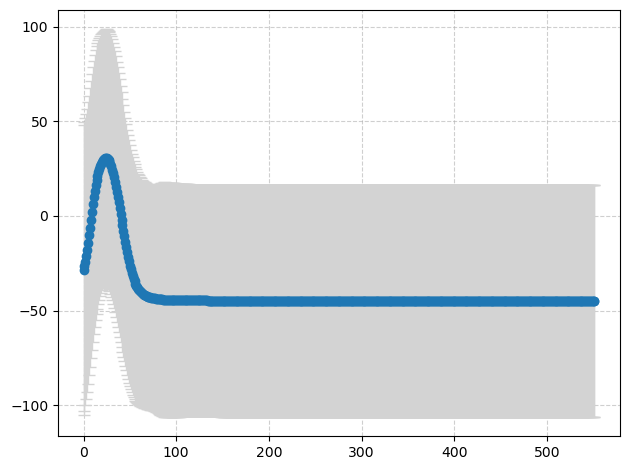

In [19]:
# Mean waves
MAX_ALLOWED = 5000

# P waves
pwaves_maxlen = min(np.max(pwaves_len), MAX_ALLOWED)
pwaves_interp = [np.interp(np.arange(pwaves_maxlen), np.arange(len(pwaves[i])), pwaves[i]) for i in tqdm(range(len(pwaves)))]
pwave_mean = np.mean(pwaves_interp, axis=0) * 1000 # Conversion from mV to microvolts
pwave_std = np.std(pwaves_interp, axis=0) * 1000 # Conversion from mV to microvolts
x = np.arange(len(pwave_mean))

del pwaves_interp

# 
plt.errorbar(
    x,
    pwave_mean,
    yerr=pwave_std,
    fmt="o",                # circle markers
    ecolor="lightgrey",         # error bar color
    elinewidth=1,           # error bar line width
    capsize=4,              # add caps to error bars
    color="tab:blue",       # main line/marker color
    markersize=6,
)

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.close()

del pwave_mean, pwave_std

100%|██████████| 97936/97936 [00:04<00:00, 21117.10it/s]


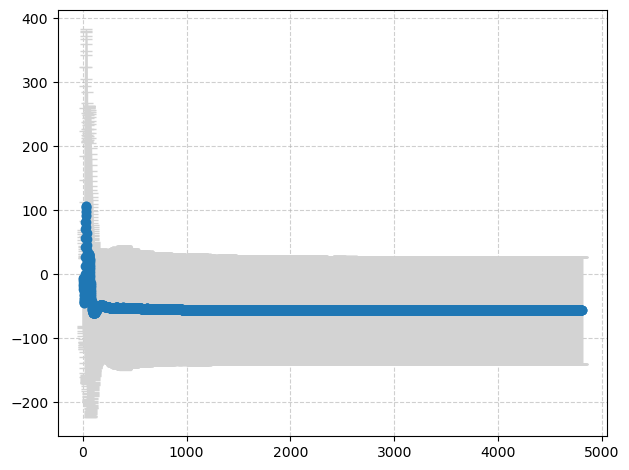

In [17]:
# Mean waves

MAX_ALLOWED = 5000

# QRS waves
qrswaves_maxlen = min(np.max(qrswaves_len), MAX_ALLOWED)
qrswaves_interp = [np.interp(np.arange(qrswaves_maxlen), np.arange(len(qrswaves[i])), qrswaves[i]) for i in tqdm(range(len(qrswaves)))]
qrswave_mean = np.mean(qrswaves_interp, axis=0) * 1000 # Conversion from mV to microvolts
qrswave_std = np.std(qrswaves_interp, axis=0)* 1000 # Conversion from mV to microvolts
x = np.arange(len(qrswave_mean))

del qrswaves_interp

# 
plt.errorbar(
    x,
    qrswave_mean,
    yerr=qrswave_std,
    fmt="o",                # circle markers
    ecolor="lightgrey",         # error bar color
    elinewidth=1,           # error bar line width
    capsize=4,              # add caps to error bars
    color="tab:blue",       # main line/marker color
    markersize=6,
)

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.close()

del qrswave_mean, qrswave_std

100%|██████████| 150227/150227 [00:02<00:00, 55600.15it/s]


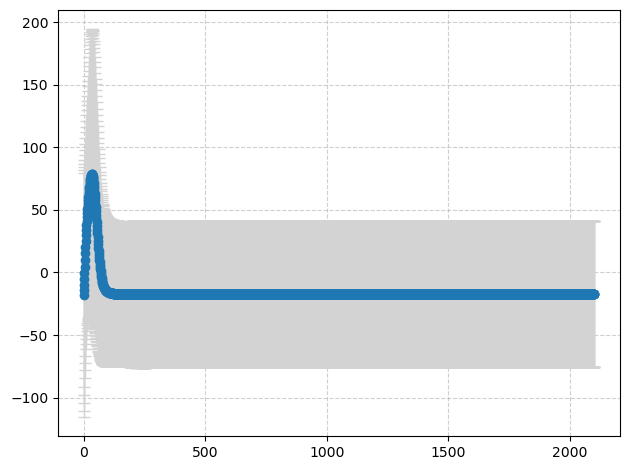

In [19]:
# Mean waves

MAX_ALLOWED = 5000

# T waves
twaves_maxlen = min(np.max(twaves_len), MAX_ALLOWED)
twaves_interp = [np.interp(np.arange(twaves_maxlen), np.arange(len(twaves[i])), twaves[i]) for i in tqdm(range(len(twaves)))]
twave_mean = np.mean(twaves_interp, axis=0)* 1000 # Conversion from mV to microvolts
twave_std = np.std(twaves_interp, axis=0)* 1000 # Conversion from mV to microvolts
x = np.arange(len(twave_mean))

del twaves_interp

# 

plt.errorbar(
    x,
    twave_mean,
    yerr=twave_std,
    fmt="o",                # circle markers
    ecolor="lightgrey",         # error bar color
    elinewidth=1,           # error bar line width
    capsize=4,              # add caps to error bars
    color="tab:blue",       # main line/marker color
    markersize=6,
)

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.close()

del twave_mean, twave_std